# Process raw renderings
## Load images

In [1]:
from pathlib import Path

working_dir = Path("C:/Users/ckobalt/Documents/MasterThesis/Spatially-Varying-Bokeh/bokehConfig")

rawRenderings_dir = working_dir / "1_rawRenderings"
cropped_dir = working_dir / "2_cropped"
blue_noise_dir = working_dir / "3_blue_noise"
blue_noise_bin_dir = working_dir / "4_blue_noise_bin"
fast_noise_dir = working_dir / "5_fast_noise"

# Create directories if they don't exist
for directory in [rawRenderings_dir, cropped_dir, blue_noise_dir, blue_noise_bin_dir, fast_noise_dir]:
    directory.mkdir(parents=True, exist_ok=True)

In [2]:
import re
from collections import defaultdict

from PIL import Image

pattern = re.compile(r"(\d+)of(\d+)\.png$", re.IGNORECASE)
groups = defaultdict(list)

for path in sorted(rawRenderings_dir.glob("*.png")):
    match = pattern.search(path.name)
    if not match:
        continue

    index, total = map(int, match.groups())
    series = path.name[: match.start()]
    with Image.open(path) as img:
        groups[(series, total)].append((index, path, img.copy()))

grouped_images = {}
for (series, total), items in groups.items():
    items.sort(key=lambda item: item[0])
    grouped_images[series] = {
        "expected_count": total,
        "images": [item[2] for item in items],
        "paths": [item[1] for item in items],
    }

print({series: len(data["images"]) for series, data in grouped_images.items()})


{'bokeh_fl45.0_as6_samples1000000_od400_lidx': 15}


### Test if renderings were correctly read

Sample series: bokeh_fl45.0_as6_samples1000000_od400_lidx


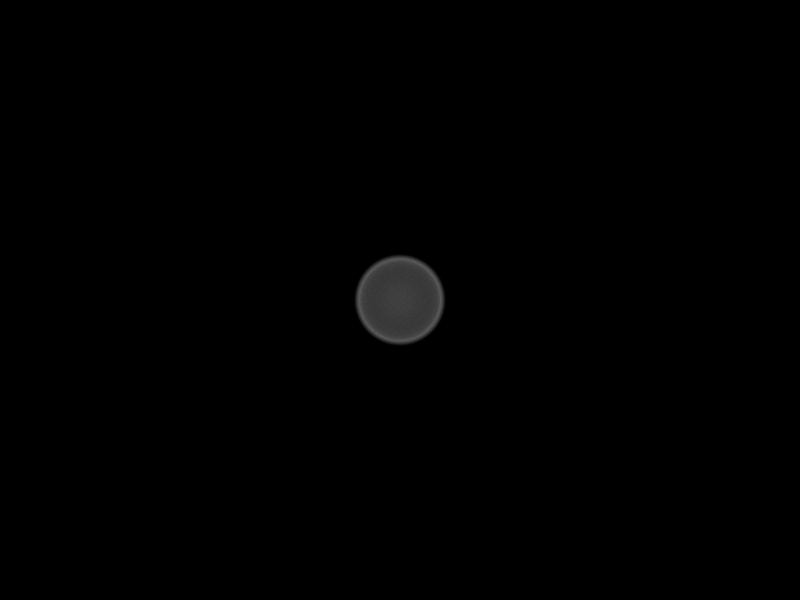

In [3]:
from IPython.display import display

first_series, data = next(iter(grouped_images.items()))
print(f"Sample series: {first_series}")
display(data["images"][0])

## Determine valid shapes and intensities

In [4]:
import numpy as np
from PIL import Image

LUMINANCE_WEIGHTS = np.array([0.2126, 0.7152, 0.0722], dtype=np.float64)

def _normalize_linear(data: np.ndarray) -> np.ndarray:
    """Scale integer arrays to [0, 1] linear space."""
    if np.issubdtype(data.dtype, np.integer):
        max_val = np.iinfo(data.dtype).max
        if max_val <= 0:
            raise ValueError(f"Non-positive max value for dtype {data.dtype}")
        return data.astype(np.float64) / max_val
    if np.issubdtype(data.dtype, np.floating):
        return data.astype(np.float64)
    raise TypeError(f"Unsupported image dtype: {data.dtype}")

def to_linear_luminance(image: Image.Image) -> np.ndarray:
    """Return a linear [0, 1] luminance array without applying gamma twice."""
    data = _normalize_linear(np.asarray(image))
    if data.ndim == 2:
        return data
    if data.ndim == 3:
        channels = data.shape[-1]
        if channels == 1:
            return np.squeeze(data, axis=-1)
        if channels == 2:
            return data[..., 0]
        if channels >= 3:
            rgb = data[..., :3]
            return rgb @ LUMINANCE_WEIGHTS
    raise ValueError(f"Unsupported image shape: {data.shape}")

def linear_luminance_to_image(linear: np.ndarray) -> Image.Image:
    """Convert a linear luminance array back to an 8-bit grayscale image."""
    scaled = np.clip(np.rint(linear * 255.0), 0, 255).astype(np.uint8)
    return Image.fromarray(scaled, mode="L")

In [5]:
import numpy as np

intensities = {}
total_shapes = 0
valid_count = 0
skipped_edge = []
skipped_empty = []

for data in grouped_images.values():
    for path, image in zip(data["paths"], data["images"]):
        total_shapes += 1
        arr = to_linear_luminance(image)
        if not np.any(arr > 0.0):
            skipped_empty.append(path.name)
            continue
        total = float(arr.sum())
        if total <= 0.0:
            skipped_empty.append(path.name)
            continue
        height, width = arr.shape
        nonzero = np.argwhere(arr > 0.0)
        min_y, min_x = nonzero.min(axis=0)
        max_y, max_x = nonzero.max(axis=0)
        if min_x == 0 or min_y == 0 or max_x == width - 1 or max_y == height - 1:
            skipped_edge.append(path.name)
            continue
        valid_count += 1
        intensities[path.name] = total

output_path = cropped_dir / "light_amounts.txt"
output_path.parent.mkdir(parents=True, exist_ok=True)

file_content = f"total {total_shapes}\nvalid {valid_count}\n"
output_path.write_text(file_content, encoding="utf-8")

print(file_content)

total 15
valid 13



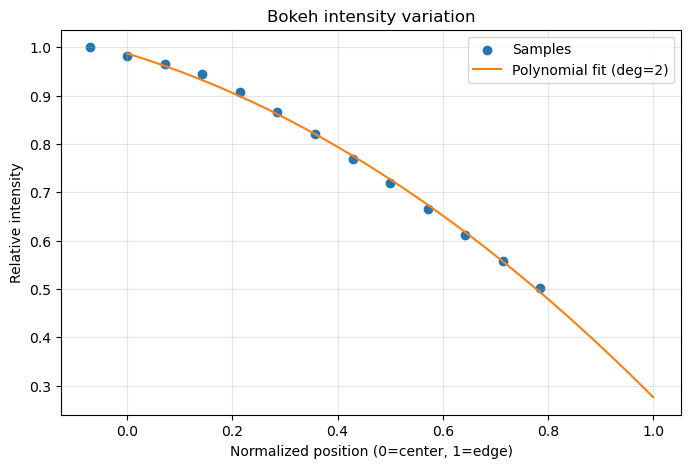

Polynomial coefficients: [-0.38046032 -0.3301857   0.98690842]
Function: f(x) = -0.38046 * x^2 + -0.330186 * x + 0.986908


In [6]:
import matplotlib.pyplot as plt
import numpy as np
import re

if not intensities:
    raise RuntimeError("Run the intensity cell first to populate the data.")

# Extract (normalized_index, intensity) pairs from filenames
pattern = re.compile(r"(\d+)of(\d+)", re.IGNORECASE)
samples = []
for name, intensity in intensities.items():
    match = pattern.search(name)
    if not match:
        continue
    index, total = map(int, match.groups())
    normalized_pos = (index - 1) / max(total - 1, 1)
    samples.append((normalized_pos, intensity))

if not samples:
    raise RuntimeError("No valid samples found for curve fitting.")

samples.sort(key=lambda item: item[0])
position_values = np.array([s[0] for s in samples], dtype=np.float64)
intensity_values = np.array([s[1] for s in samples], dtype=np.float64)

# Normalize intensities relative to first sample (position 0)
first_intensity = intensity_values[0]
relative_intensity = intensity_values / first_intensity

# Fit polynomial
poly_degree = 2
poly_coeffs = np.polyfit(position_values, relative_intensity, deg=poly_degree)
fit_grid = np.linspace(0.0, 1.0, num=200)
fit_curve = np.polyval(poly_coeffs, fit_grid)

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(position_values, relative_intensity, label="Samples", color="#1f77b4")
plt.plot(fit_grid, fit_curve, label=f"Polynomial fit (deg={poly_degree})", color="#ff7f0e")
plt.xlabel("Normalized position (0=center, 1=edge)")
plt.ylabel("Relative intensity")
plt.title("Bokeh intensity variation")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Build function string
powers = np.arange(poly_coeffs.size - 1, -1, -1)
terms = []
for coeff, power in zip(poly_coeffs, powers):
    if abs(coeff) < 1e-12:
        continue
    if power == 0:
        terms.append(f"{coeff:.6g}")
    elif power == 1:
        terms.append(f"{coeff:.6g} * x")
    else:
        terms.append(f"{coeff:.6g} * x^{power}")
function_repr = " + ".join(terms) if terms else "0"

# Append polynomial to the light_amounts file
with output_path.open("a", encoding="utf-8") as f:
    f.write(f"intensity_polynomial {' '.join(f'{c:.6g}' for c in poly_coeffs)}\n")
    f.write(f"intensity_function {function_repr}\n")

print(f"Polynomial coefficients: {poly_coeffs}")
print(f"Function: f(x) = {function_repr}")

### Crop bokeh and save as .pgm

In [7]:
import numpy as np
from pathlib import Path

def save_pgm_ascii(path: Path, data: np.ndarray, max_value: int = 255) -> None:
    array = np.asarray(data)
    if array.ndim != 2:
        raise ValueError("PGM images must be 2D arrays")
    clipped = np.clip(array, 0, max_value).astype(np.uint8)
    height, width = clipped.shape
    header = f"P2\n{width} {height}\n{max_value}\n"
    body = "\n".join(" ".join(str(int(pixel)) for pixel in row) for row in clipped)
    path.write_text(header + body + "\n", encoding="ascii")

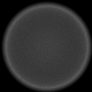

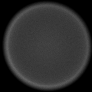

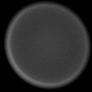

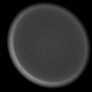

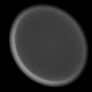

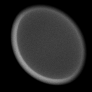

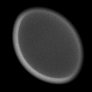

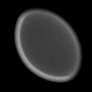

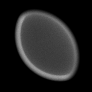

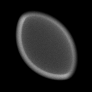

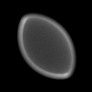

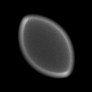

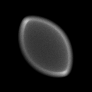

Cropped and saved 13 valid shapes to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\2_cropped


In [8]:
from PIL import ImageOps
from IPython.display import display

cropped_dir.mkdir(parents=True, exist_ok=True)

crop_boxes = {}
reference_side = None

for data in grouped_images.values():
    for path, image in zip(data["paths"], data["images"]):
        # Skip invalid shapes (not in intensities dict)
        if path.name not in intensities:
            continue
        
        linear_gray = to_linear_luminance(image)
        gray_image = linear_luminance_to_image(linear_gray)
        
        # Calculate intensity-weighted centroid
        total_intensity = linear_gray.sum()
        y_idx, x_idx = np.indices(linear_gray.shape)
        cx = float((linear_gray * x_idx).sum() / total_intensity)
        cy = float((linear_gray * y_idx).sum() / total_intensity)
        
        # Determine crop size from bounding box
        ys, xs = np.nonzero(linear_gray > 0.0)
        side = max(int(round(max(np.ptp(xs), np.ptp(ys))) + 1), 1)
        reference_side = reference_side or side
        side = min(reference_side, linear_gray.shape[0], linear_gray.shape[1])
        
        # Calculate crop box centered on intensity-weighted centroid
        half = side / 2.0
        left, top = int(round(cx - half)), int(round(cy - half))
        right, bottom = left + side, top + side
        
        # Handle padding if crop extends beyond image bounds
        padding = (
            max(0, -left),
            max(0, -top),
            max(0, right - linear_gray.shape[1]),
            max(0, bottom - linear_gray.shape[0]),
        )
        padded = ImageOps.expand(gray_image, border=padding, fill=0) if any(padding) else gray_image
        box = (
            left + padding[0],
            top + padding[1],
            right + padding[0],
            bottom + padding[1],
        )
        crop_boxes[path] = (padding, box)
        cropped = padded.crop(box)
        inverted = ImageOps.invert(cropped)
        
        # Display preview
        display(cropped)
        
        # Save as PGM (inverted) and PNG (normal)
        save_pgm_ascii(cropped_dir / f"{path.stem}.pgm", np.asarray(inverted))
        cropped.save(cropped_dir / f"{path.stem}.png", format="PNG")

print(f"Cropped and saved {len(crop_boxes)} valid shapes to {cropped_dir}")

### Generate batch scripts to generate noise for the first shape

In [16]:
bat_path = working_dir / "3_generate_noise.bat"
fastnoise_root = working_dir.parent.parent / "fastnoise"

pgm_files = sorted(cropped_dir.glob("*.pgm"))
if not pgm_files:
    print("No PGM files found in cropped_dir")
else:
    first_pgm = pgm_files[0]
    input_stem = first_pgm.stem
    output_name = "base_bokeh"
    
    lines = [
        "echo Step 1: Generating blue noise...",
        f"for /l %%x in (0, 1, 31) do ..\\Utils\\agbn\\agbn.exe -F 0 {cropped_dir / input_stem}.pgm 16384 1000 {blue_noise_dir / output_name}_%%x.txt {blue_noise_dir / output_name}_%%x.png",
        "",
        "echo Step 2: Packing blue noise to bin...",
        f"..\\Utils\\Gbn2Bin\\x64\\Release\\Gbn2Bin.exe {blue_noise_dir / output_name}_ {blue_noise_bin_dir / output_name}",
        "",
        "echo Step 3: Running FastNoise...",
        f"pushd \"{fastnoise_root}\"",
        (
            "FastNoise.exe Vector2 Uniform gauss 1.0 exponential 0.1 0.1 separate "
            f"0.5 128 128 32 {output_name} -split -init \"{blue_noise_bin_dir / output_name}.bin\" -progress 1"
        ),
        f"for %%f in (\"{output_name}*\") do move /Y \"%%f\" \"{fast_noise_dir}\"",
        "popd",
        "",
        "echo Done!",
        "pause",
    ]
    
    bat_path.write_text("\n".join(lines), encoding="utf-8")
    print(f"Wrote all commands to {bat_path}")

Wrote all commands to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\3_generate_noise.bat
